## Convert midi file into pandas dataframe
*same method also works with mido tracks or list of midi messages stored as dictionaries*

In [966]:
import pandas as pd
import mido

# can't iterate directly on midi file
# because it converts ticks to seconds
midi_file = mido.MidiFile('test.mid')
df = pd.DataFrame([
    # create a list of dictionaries which can be interpreted by pandas
    message.dict() for message in midi_file.tracks[0] if not message.is_meta
])


## Wrangle dataframe

In [967]:
import numpy as np
from sklearn.impute import KNNImputer


# create a category type which enumarates labels in user defined order
type_names = ['note_on', 'note_off', 'control_change']
cat_type = pd.CategoricalDtype(type_names, ordered=True)
# create a new series with the category codes in new variable
wrangled_df = df
wrangled_df['type_codes'] = df['type'].astype(cat_type).cat.codes

# create a new series with shifted codes to use next code
# as current code and predict future
wrangled_df = wrangled_df.drop(['type', 'channel'], axis=1)
wrangled_df = pd.concat(
    # TODO check if it makes sense to use imputer 
    # instead of simple value replacement
    [wrangled_df, wrangled_df.shift(-1).add_prefix('next_')], axis=1
).drop(wrangled_df.tail(1).index)

imputer = KNNImputer(n_neighbors=2)
imputed_array = imputer.fit_transform(wrangled_df)
imputed_df = pd.DataFrame(imputed_array, columns=wrangled_df.columns).astype('int')

imputed_df



,time,note,velocity,control,value,type_codes,next_time,next_note,next_velocity,next_control,next_value,next_type_codes
0,6841,72,10,42,95,0,660,72,0,23,64,1
1,660,72,0,42,32,1,837,58,74,42,32,0
2,837,58,74,20,64,0,253,58,0,20,64,1
3,253,58,0,32,63,1,1310,72,34,10,32,0
4,1310,72,34,10,32,0,310,72,0,10,33,1
...,...,...,...,...,...,...,...,...,...,...,...,...
529,58,60,0,21,64,2,0,64,0,21,63,2
530,0,63,16,21,63,2,610,66,17,21,64,2
531,610,63,14,21,64,2,0,63,16,21,63,2
532,0,69,0,21,63,2,301,63,27,21,64,2


In [968]:
wrangled_df.to_csv('test.csv')


## Create actual training data tables

In [969]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# take column to use as target for predictions
target = imputed_df['next_type_codes']


## Train KNN model for msg type parameter and test for accuracy
*KNN does support multioutput classification (not regression) but it's accuracy evaluation method does not*

In [970]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
# import SimpleImputer to replace NaN because not accepted in KNN
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

# test different settings
for n_neighbors in neighbors_settings:
    type_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    type_knn.fit(X_train, y_train)
    training_accuracy.append(type_knn.score(X_train, y_train))
    test_accuracy.append(type_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
type_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
type_knn.fit(X_train, y_train)

type_knn.predict(X_test).astype('int')


array([2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 0, 2, 2, 0, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

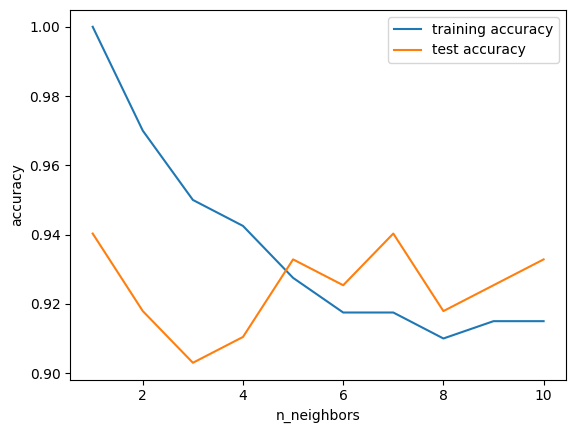

In [971]:
# plotting
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (Note value)

In [972]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data['next_type_codes'] = imputed_df['next_type_codes']
# take column to use as target for predictions
target = imputed_df['next_note']


## Train KNN model for note number parameter and test for accuracy

In [973]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    note_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    note_knn.fit(X_train, y_train)
    training_accuracy.append(note_knn.score(X_train, y_train))
    test_accuracy.append(note_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
note_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
note_knn.fit(X_train, y_train)

note_knn.predict(X_test).astype('int')


array([64, 72, 64, 64, 64, 72, 66, 66, 64, 64, 64, 64, 64, 64, 64, 64, 64,
       66, 64, 64, 64, 64, 68, 69, 66, 66, 64, 64, 64, 64, 64, 66, 64, 64,
       64, 64, 66, 64, 64, 64, 69, 64, 64, 64, 64, 62, 64, 64, 64, 69, 64,
       64, 64, 64, 64, 64, 64, 64, 68, 64, 64, 64, 64, 63, 64, 64, 64, 64,
       64, 66, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 64, 63, 64, 64,
       64, 64, 64, 64, 64, 62, 64, 64, 66, 64, 66, 64, 64, 66, 64, 64, 64,
       64, 64, 66, 64, 64, 64, 66, 69, 63, 64, 64, 58, 66, 64, 71, 64, 64,
       58, 64, 64, 64, 64, 64, 64, 64, 68, 68, 64, 64, 64, 64, 64])

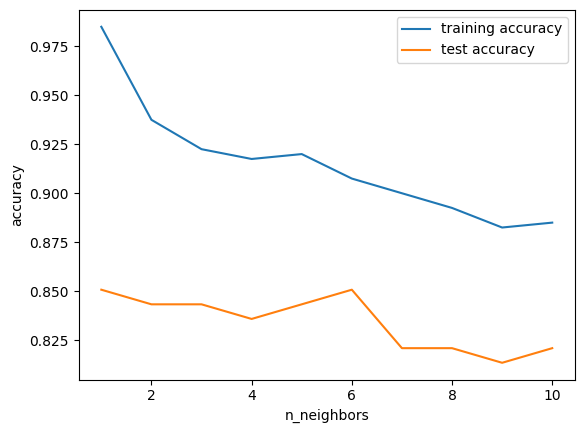

In [974]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (Note velocity)

In [975]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data[['next_type_codes', 'next_note']] = imputed_df[['next_type_codes', 'next_note']]
# take column to use as target for predictions
target = imputed_df['next_velocity']


## Train KNN model for note velocity parameter and test for accuracy

In [976]:
from sklearn.neighbors import KNeighborsRegressor

X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    velocity_knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    velocity_knn.fit(X_train, y_train)
    training_accuracy.append(velocity_knn.score(X_train, y_train))
    test_accuracy.append(velocity_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
velocity_knn = KNeighborsRegressor(n_neighbors=highest_score_index)
velocity_knn.fit(X_train, y_train)

velocity_knn.predict(X_test).astype('int')


array([ 0,  0,  0, 36, 11, 10,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0, 36,  0,  0, 40,  0,  0,  0,  0,  3,  0,  0,  0,  0,  0,  0,  0,
        0,  7,  0,  0,  0,  0,  0, 19,  0,  0,  0,  7,  0,  0,  0, 40,  0,
       41, 26,  0,  0,  0,  0,  0,  0,  0, 41, 40,  0,  0, 16,  0,  0, 41,
        0,  0,  0, 10,  0,  0,  0,  0, 38,  3,  0,  0,  1, 40,  0,  0,  0,
        1,  0,  0, 26,  0, 16,  5, 11,  0, 14, 26,  0,  0,  8,  8, 34,  0,
        0,  0,  0,  0, 26,  0,  0,  0, 38, 38,  0,  0,  0,  0,  0, 23,  0,
        0,  0,  0,  0,  0, 40,  0,  0,  0,  0,  0,  0,  0,  0,  0])

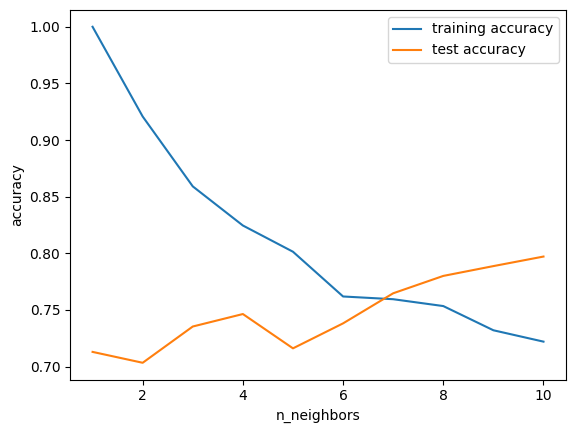

In [977]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (cc number)

In [978]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data['next_type_codes'] = imputed_df['next_type_codes']
# take column to use as target for predictions
target = imputed_df['next_control']


## Train KNN model for note number parameter and test for accuracy

In [979]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    control_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    control_knn.fit(X_train, y_train)
    training_accuracy.append(control_knn.score(X_train, y_train))
    test_accuracy.append(control_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
control_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
control_knn.fit(X_train, y_train)

control_knn.predict(X_test).astype('int')


array([20, 21, 26, 26, 21, 10,  1, 21, 26, 20, 26, 21, 21, 21, 21, 21, 20,
       21,  1, 21, 25, 21,  1, 25, 21,  1,  1, 21, 21, 20, 21, 21,  1, 21,
       21, 21, 20,  1, 21, 21, 21, 11, 26,  1,  1, 20, 20,  1, 21, 21,  1,
       20,  1, 21, 21, 21, 26,  1, 25, 21,  1, 21, 21, 20,  1, 21, 21, 21,
       26, 21, 21,  1, 21,  1, 20,  1, 13, 21,  1, 20, 21,  1, 25, 25,  1,
       21, 21, 20, 21, 26, 21, 21,  1,  1, 25, 21, 21,  1,  1,  1, 25, 21,
       26, 25, 21, 21,  1, 21, 26, 10, 20, 20, 26,  1,  1, 21, 21, 10,  1,
       20,  1, 20,  1,  1,  1, 26, 21, 20, 21, 13, 26, 21, 21, 21])

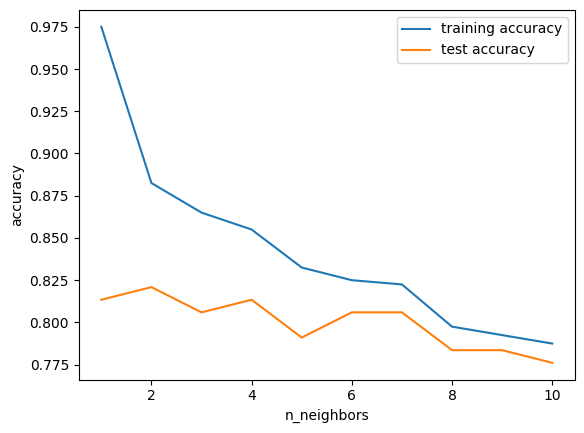

In [980]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (cc number)

In [981]:
# exclude second half of columns ('next_' values)
data = imputed_df.iloc[:,:int(imputed_array.shape[1] / 2)]
# but include next_type_codes to use the generated 
# data point for next_type_codes to predict next_note
data[['next_type_codes', 'next_control']] = imputed_df[['next_type_codes', 'next_control']]
# take column to use as target for predictions
target = imputed_df['next_value']


## Train KNN model for note number parameter and test for accuracy

In [982]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    value_knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    value_knn.fit(X_train, y_train)
    training_accuracy.append(value_knn.score(X_train, y_train))
    test_accuracy.append(value_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
value_knn = KNeighborsClassifier(n_neighbors=highest_score_index)
value_knn.fit(X_train, y_train)

value_knn.predict(X_test).astype('int')


array([ 65,  44,  63,  64,  63,  98,  43,  65,  64,  64, 105,  63,  63,
        64,  64,  64,  32,  64,  47,  35,  12,  63,  98,  63,  63,  64,
        63,  92,   6,  64,  53,  63,  63, 115,  66,  63,  64,  64,  95,
        64,  78,  64,  64,  47,  64,  93,  69,  24,  27,  64,  64,  63,
        63,  64,  92,  63,  31,  64,  75, 124,  64,  64,  32,  64,  64,
        64,  65,  33,  63, 108,  63,  66,  61,  63,  37,  65,  64,  63,
        64,  62,  63,  72,  63,  63,  64,  63,  84,  98,  63,  64,  33,
        40,  65,  64,  64,  64,  64,  64,  65,  61,   9, 125,  80,  80,
        63,  65,  65,  64,  63,  59, 110,  63,  64,  93,  16,  32,  64,
        63,  50,  63,  64,  21,  32,  55,  64,  64,  64,  21,  65,  63,
        64,  65,  64,  64])

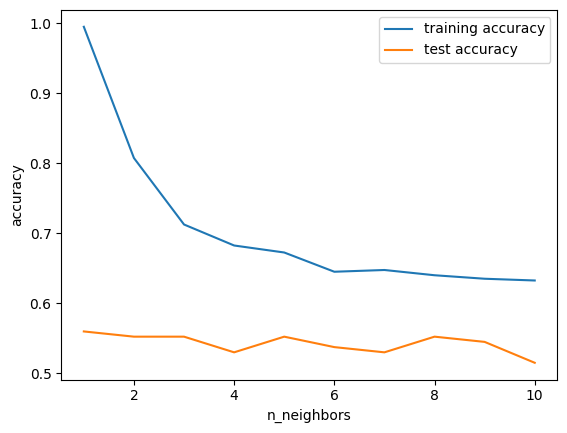

In [983]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Create data table to predict next parameter (time)

In [984]:
# exclude second half of columns ('next_' values)
data = imputed_df.drop('next_time', axis=1)
# take column to use as target for predictions
target = imputed_df['next_time']


## Train KNN model for note number parameter and test for accuracy

In [985]:
X_train, X_test, y_train, y_test = train_test_split(data, target)

# variables to test accuracy
training_accuracy = []
test_accuracy = []
neighbors_settings = range(1, 11)

for n_neighbors in neighbors_settings:
    time_knn = KNeighborsRegressor(n_neighbors=n_neighbors)
    time_knn.fit(X_train, y_train)
    training_accuracy.append(time_knn.score(X_train, y_train))
    test_accuracy.append(time_knn.score(X_test, y_test))

# use best setting
highest_score_index = test_accuracy.index(max(test_accuracy)) + 1
time_knn = KNeighborsRegressor(n_neighbors=highest_score_index)
time_knn.fit(X_train, y_train)

time_knn.predict(X_test).astype('int')


array([   1,   28,    0,    9,   11,    9,   71,    9,    1,    0,  121,
          0,    0,   11,    0,   41,   26,    1,    0,  745,    0,   18,
          0,  160,   26,   41,  101,   28,    0,  226,   26,   41,   41,
          1, 1010,    0,    1,    0,    0,    0,   12,  921,    0,  178,
          0,   26,   49,   75,   41,    0,    0,    0,    0, 1167,   11,
          0,   14,    1,   41,   41,    0,  124,    7,    1,   75,   41,
         41,    0,    0,  107,  347,   26,  107,  679,   24,    0,  318,
          1,   18,    1,    0,    0, 1010,    0,    0,    0,  124,    0,
          1,  347,  503,    0,    0,   41,  745,   41,    0,    0, 1167,
          1,  126,    1,   43,   41,    0, 1010,    0,   10,    0,  745,
         41,    0,    0,    0,    0,   41,   26,  142,   41,    0,   75,
          0,    9,    0,    0,    0,   18,  318,   41,    1,    0,   18,
        943,    0])

In [986]:
X_train


,time,note,velocity,control,value,type_codes,next_note,next_velocity,next_control,next_value,next_type_codes
132,1,60,0,1,73,2,64,0,1,74,2
158,1,60,0,1,99,2,64,0,1,100,2
18,460,68,28,21,64,0,66,0,21,63,1
232,0,60,0,25,62,2,64,0,25,64,2
62,1,60,0,1,3,2,64,0,1,4,2
...,...,...,...,...,...,...,...,...,...,...,...
125,1,60,0,1,66,2,64,0,1,67,2
221,20,60,0,25,64,2,64,0,25,63,2
147,1,60,0,1,88,2,64,0,1,89,2
291,100,64,0,26,64,2,66,41,26,65,2


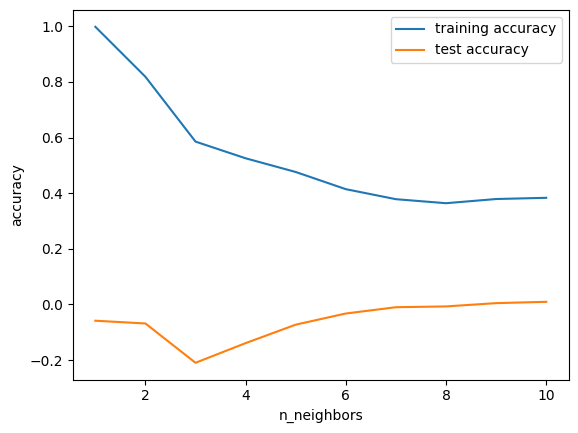

In [987]:
plt.plot(neighbors_settings, training_accuracy, label='training accuracy')
plt.plot(neighbors_settings, test_accuracy, label='test accuracy')
plt.ylabel('accuracy')
plt.xlabel('n_neighbors')
plt.legend()


## Making complete prediction

In [ ]:
import mido

midi_file = mido.MidiFile()
midi_track = mido.MidiTrack()
midi_file.tracks.append([midi_track])

# last row of data, not used for training nor testing
X_new = imputed_df.iloc[-1:,:int(imputed_array.shape[1] / 2)]

new_type = type_knn.predict(X_new).squeeze()
X_new['next_type_codes'] = new_type
new_control = control_knn.predict(X_new).squeeze()
X_new['next_control'] = new_control
new_value = value_knn.predict(X_new).squeeze()
X_new.drop('next_control', axis=1, inplace=True)
new_note = note_knn.predict(X_new).squeeze()
X_new['next_note'] = new_note
new_velocity = velocity_knn.predict(X_new).squeeze()
X_new['next_velocity'] = new_velocity
X_new['next_control'] = new_control
X_new['next_value'] = new_value
X_new.drop('next_type_codes', axis=1, inplace=True)
X_new['next_type_codes'] = new_type
new_time = time_knn.predict(X_new).squeeze()
X_new['next_time'] = new_time
X_new = X_new.iloc[:,int(imputed_array.shape[1] / 2):]
X_new.columns = X_new.columns.str.removeprefix('next_')

new_msg = X_new
new_msg['type'] = type_names[new_msg['type_codes'].iloc[-1]]
new_msg.drop('type_codes', axis=1, inplace=True)
new_msg = new_msg.to_dict(orient='records')[0]
if new_msg['type'] in ['note_on', 'note_off']:
    new_msg.pop('control', None)
    new_msg.pop('value', None)
elif new_msg['type'] == 'control_change':
    new_msg.pop('note', None)
    new_msg.pop('velocity', None)

midi_track.append(mido.Message(**new_msg))


In [ ]:

new_message = {
    'type': type_names[new_type]
}
new_message


{'type': 'control_change'}